# Notebook 05: ENDF Loading and Multi-L Resonances

This notebook demonstrates loading evaluated nuclear data (ENDF) directly from
the IAEA database, using the full resonance parameter set (all L-groups) for
cross-section calculations.

## Prerequisites

```bash
pixi run build
```

## What's New

Previous notebooks used `create_resonance_data()` with manually transcribed
parameters (single resonance, L=0 only). This notebook uses:

- **`load_endf(z, a)`** — fetch + parse ENDF data from the IAEA, with local caching
- **`load_endf_file(path)`** — parse a local ENDF file
- **`create_resonance_data(..., target_spin=, l_groups=)`** — multi-L manual construction

In [1]:
import nereids
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 1. Loading U-238 from the IAEA

The `load_endf()` function downloads an ENDF file from the IAEA Nuclear Data
Services, parses the resonance parameters (MF=2, MT=151), and returns a
`ResonanceData` object. Files are cached at `~/.cache/nereids/endf/` so
subsequent calls are instant.

The default library is **ENDF/B-VIII.0**, which is well-tested and widely used.
JEFF-3.3 and JENDL-5 are also available.

In [2]:
# Fetch U-238 from IAEA (or cache)
u238 = nereids.load_endf(92, 238)
print(u238)
print(f"  L values:          {u238.l_values}")
print(f"  Target spin:       {u238.target_spin}")
print(f"  Scattering radius: {u238.scattering_radius}")
print(f"  Total resonances:  {u238.n_resonances}")

ResonanceData(Z=92, A=238, AWR=236.006, n_resonances=3345)
  L values:          [0, 1]
  Target spin:       0.0
  Scattering radius: 0.0
  Total resonances:  3345


U-238 has **two L-groups** (L=0 s-wave and L=1 p-wave) with thousands of
resonances. Compare this to notebook 01 where we manually entered a single
resonance at 6.674 eV.

## 2. Full ENDF vs Single-Resonance Cross-Sections

Let's compare the full ENDF U-238 cross-sections against the single-resonance
approximation from notebook 01.

In [3]:
# Single-resonance model from notebook 01
u238_single = nereids.create_resonance_data(
    z=92, a=238, awr=236.006, scattering_radius=9.4285,
    resonances=[(6.674, 0.5, 1.493e-3, 23.0e-3)]
)

# Energy grid: 1–50 eV (covers many resonances)
energies = np.geomspace(1.0, 50.0, 5000)

# Compute cross-sections
xs_full = nereids.cross_sections(energies, u238)
xs_single = nereids.cross_sections(energies, u238_single)

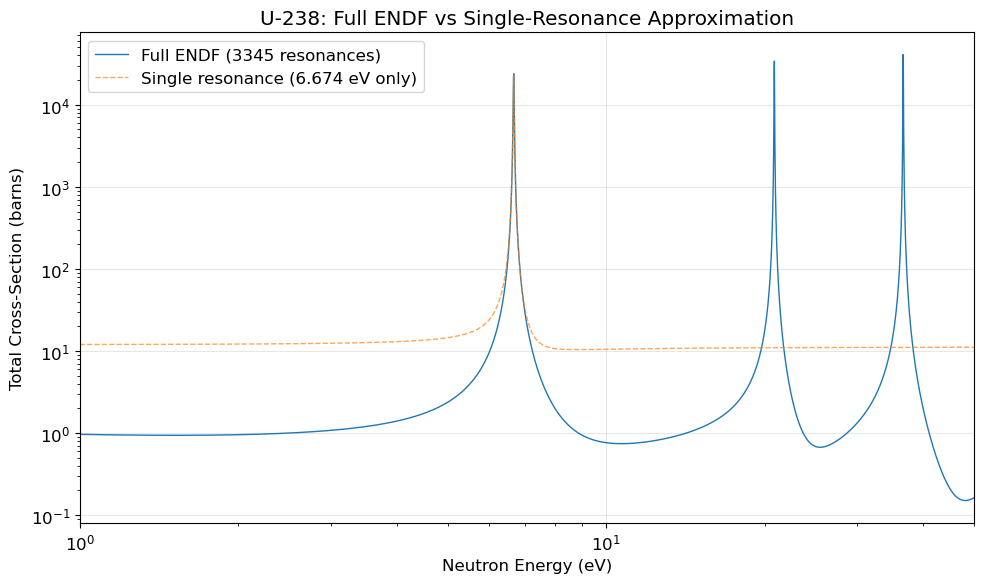

In [4]:
fig, ax = plt.subplots()
ax.loglog(energies, xs_full['total'], label='Full ENDF (3345 resonances)', linewidth=1.0)
ax.loglog(energies, xs_single['total'], '--', label='Single resonance (6.674 eV only)',
          linewidth=1.0, alpha=0.7)

ax.set_xlabel('Neutron Energy (eV)')
ax.set_ylabel('Total Cross-Section (barns)')
ax.set_title('U-238: Full ENDF vs Single-Resonance Approximation')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(1, 50)
plt.tight_layout()
plt.show()

The full ENDF data reveals a rich forest of resonances above ~6 eV, each
corresponding to a compound nuclear state. The single-resonance model only
captures the dominant 6.674 eV peak.

## 3. Loading Pu-241

NEREIDS has ~40 built-in MAT numbers for commonly used isotopes. For isotopes
not in the table, provide the MAT number explicitly via `mat=`.

In [5]:
# Pu-241: important for spent fuel characterization
pu241 = nereids.load_endf(94, 241)
print(pu241)
print(f"  L values:          {pu241.l_values}")
print(f"  Target spin:       {pu241.target_spin}")
print(f"  Total resonances:  {pu241.n_resonances}")

ResonanceData(Z=94, A=241, AWR=238.978, n_resonances=244)
  L values:          [0]
  Target spin:       2.5
  Total resonances:  244


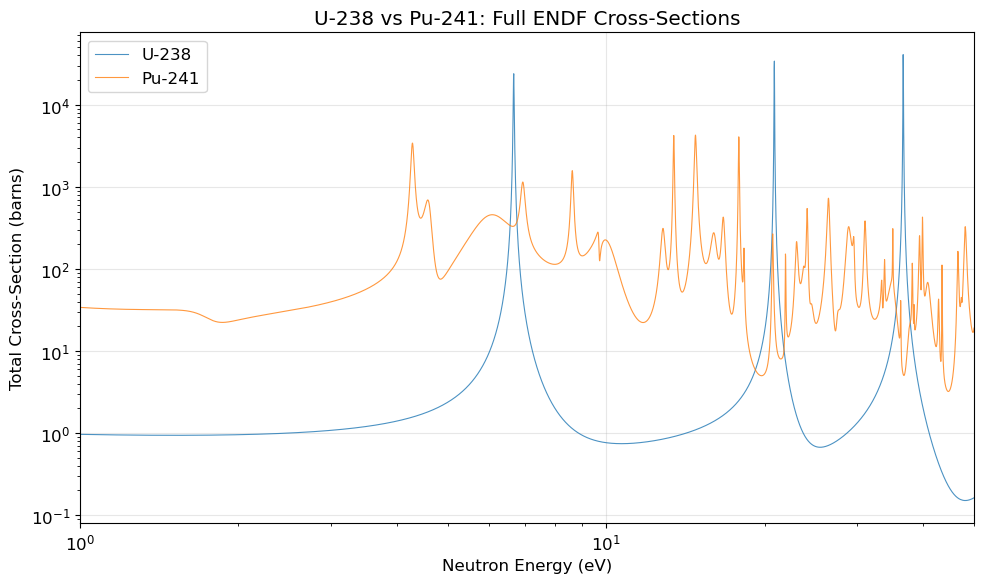

In [6]:
# Compare U-238 and Pu-241 total cross-sections
xs_pu241 = nereids.cross_sections(energies, pu241)

fig, ax = plt.subplots()
ax.loglog(energies, xs_full['total'], label='U-238', linewidth=0.8, alpha=0.8)
ax.loglog(energies, xs_pu241['total'], label='Pu-241', linewidth=0.8, alpha=0.8)

ax.set_xlabel('Neutron Energy (eV)')
ax.set_ylabel('Total Cross-Section (barns)')
ax.set_title('U-238 vs Pu-241: Full ENDF Cross-Sections')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(1, 50)
plt.tight_layout()
plt.show()

## 4. Transmission with Full ENDF Data

The real power of loading full ENDF data is computing realistic transmission
spectra. This is the fundamental measurement in neutron resonance imaging.

In [7]:
# Compute transmission for a sample with both isotopes
# Areal densities matching the PLEIADES test data:
#   U-235: 0.001025 atoms/barn
#   Pu-241: 0.0004998 atoms/barn

u235 = nereids.load_endf(92, 235)
print(u235)
print(f"  L values: {u235.l_values}, Target spin: {u235.target_spin}, Resonances: {u235.n_resonances}")

# Forward model: Beer-Lambert with Doppler broadening at 293.6 K
transmission = nereids.forward_model(
    energies,
    [(u235, 0.001025), (pu241, 0.0004998)],
    temperature_k=293.6,
)

ResonanceData(Z=92, A=235, AWR=233.025, n_resonances=3195)
  L values: [0], Target spin: 3.5, Resonances: 3195


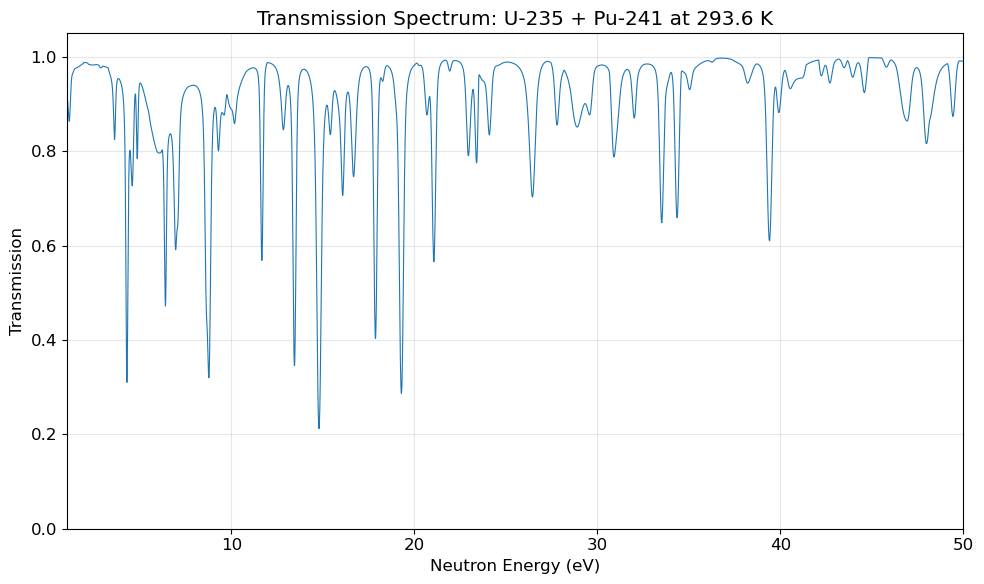

In [8]:
fig, ax = plt.subplots()
ax.plot(energies, transmission, linewidth=0.8)
ax.set_xlabel('Neutron Energy (eV)')
ax.set_ylabel('Transmission')
ax.set_title('Transmission Spectrum: U-235 + Pu-241 at 293.6 K')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, 50)
plt.tight_layout()
plt.show()

## 5. Multi-L Manual Construction with `create_resonance_data()`

The `create_resonance_data()` function now supports:
- **`target_spin`** — nuclear spin of the target (default 0.0)
- **`l_groups`** — list of `(l_value, [(E, J, Gn, Gg), ...])` tuples

This is useful when you have specific resonance parameters (e.g. from a SAMMY
analysis) rather than an ENDF file.

In [9]:
# Create U-238 with L=0 and L=1 resonances manually
u238_manual = nereids.create_resonance_data(
    z=92, a=238, awr=236.006, scattering_radius=9.4285,
    resonances=[],  # ignored when l_groups is provided
    target_spin=0.0,
    l_groups=[
        (0, [
            (6.674, 0.5, 1.493e-3, 23.0e-3),    # s-wave resonance
            (20.87, 0.5, 10.26e-3, 22.86e-3),   # another s-wave
            (36.68, 0.5, 33.55e-3, 23.36e-3),   # another s-wave
        ]),
        (1, [
            (10.23, 1.5, 0.002e-3, 24.0e-3),    # p-wave resonance
            (11.31, 0.5, 0.0002e-3, 24.0e-3),   # p-wave resonance
        ]),
    ]
)
print(u238_manual)
print(f"  L values: {u238_manual.l_values}")
print(f"  Target spin: {u238_manual.target_spin}")
print(f"  Resonances: {u238_manual.n_resonances}")

ResonanceData(Z=92, A=238, AWR=236.006, n_resonances=5)
  L values: [0, 1]
  Target spin: 0.0
  Resonances: 5


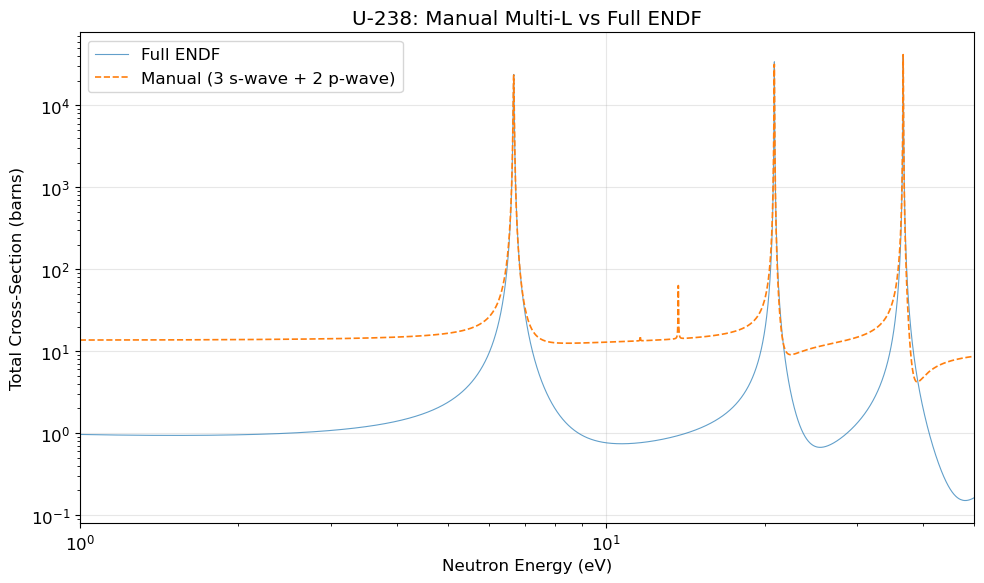

In [10]:
# Compare with ENDF data in the same energy range
E_compare = np.geomspace(1.0, 50.0, 5000)
xs_manual = nereids.cross_sections(E_compare, u238_manual)
xs_endf = nereids.cross_sections(E_compare, u238)

fig, ax = plt.subplots()
ax.loglog(E_compare, xs_endf['total'], label='Full ENDF', linewidth=0.8, alpha=0.7)
ax.loglog(E_compare, xs_manual['total'], '--', label='Manual (3 s-wave + 2 p-wave)',
          linewidth=1.2)

ax.set_xlabel('Neutron Energy (eV)')
ax.set_ylabel('Total Cross-Section (barns)')
ax.set_title('U-238: Manual Multi-L vs Full ENDF')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(1, 50)
plt.tight_layout()
plt.show()

## 6. Loading from Local ENDF Files

If you have a local ENDF file (e.g. from SAMMY), use `load_endf_file()`.

In [11]:
import os

# Try loading the SAMMY ex027 ENDF file (if available)
sammy_endf = os.path.join('..', '..', '..', 'SAMMY', 'SAMMY', 'samexm_new', 'ex027_new', 'ex027.endf')

if os.path.exists(sammy_endf):
    u238_sammy = nereids.load_endf_file(sammy_endf)
    print(f"SAMMY ENDF: {u238_sammy}")
    print(f"  L values: {u238_sammy.l_values}")
    print(f"  Scattering radius: {u238_sammy.scattering_radius:.6f} fm")
    print(f"  Resonances: {u238_sammy.n_resonances}")
else:
    print(f"SAMMY ENDF file not found at {sammy_endf}")
    print("Skipping local file test (this is expected in CI)")

SAMMY ENDF: ResonanceData(Z=92, A=238, AWR=236.006, n_resonances=1653)
  L values: [0, 1]
  Scattering radius: 0.942848 fm
  Resonances: 1653


## 7. Supported Libraries and MAT Numbers

### ENDF Libraries

| Library | String | Notes |
|---------|--------|-------|
| ENDF/B-VIII.0 | `"endf8.0"` | Default, well-tested |
| ENDF/B-VIII.1 | `"endf8.1"` | Latest release (Aug 2024) |
| JEFF-3.3 | `"jeff3.3"` | European library |
| JENDL-5 | `"jendl5"` | Japanese library |

### Built-in MAT Numbers (~40 isotopes)

The following isotopes have built-in MAT numbers and can be loaded with just
`load_endf(z, a)`. For other isotopes, provide `mat=` explicitly.

| Isotope | MAT | Isotope | MAT |
|---------|-----|---------|-----|
| H-1 | 125 | Zr-90 | 4025 |
| Li-6 | 325 | Nb-93 | 4125 |
| B-10 | 525 | Ag-107 | 4725 |
| C-12 | 625 | In-115 | 4931 |
| Al-27 | 1325 | Ta-181 | 7328 |
| Fe-56 | 2631 | W-184 | 7431 |
| Ni-58 | 2825 | Au-197 | 7925 |
| Cu-63 | 2925 | U-235 | 9228 |
| Hf-177 | 7231 | U-238 | 9237 |
| Th-232 | 9040 | Pu-239 | 9437 |

Full list in [retrieval.rs](../../crates/nereids-endf/src/retrieval.rs).

## Summary

This notebook demonstrated:

1. **`load_endf(z, a)`** — one-line ENDF retrieval with IAEA download + local cache
2. **Full resonance spectra** — thousands of resonances across L=0 and L=1 groups
3. **Multi-isotope comparison** — U-238 vs Pu-241 side-by-side
4. **Realistic transmission** — full ENDF data with Doppler broadening
5. **`create_resonance_data(..., l_groups=)`** — manual multi-L construction
6. **`load_endf_file(path)`** — loading local ENDF files
7. **Library and MAT reference** — supported ENDF libraries and isotope table

**Next**: [03_spectrum_fitting.ipynb](03_spectrum_fitting.ipynb) — fitting measured spectra to recover isotopic compositions.